This notebook extends H_E_graph.ipynb to constrained problems

In [1]:
# imports
import itertools
import matplotlib.pyplot as plt
import numpy as np
import tqdm
import joblib

# imports from qemcmc
from qemcmc.model import EnergyModel, ConstraintModel,ModelMaker
from qemcmc.sampler import QeProposal, ClassicalProposal
from qemcmc.coarse_grain import CoarseGraining


# Initialise Constrained Model
First we initialise an unconstrained random fully connected Ising model


In [29]:
n_spins = 9  # Number of spins in the system

base_model  = ModelMaker(n_spins, "Fully Connected Ising", "example model").model

Then we have to define the constraints

In [30]:


shape_of_J = (n_spins, n_spins)
J_constraint = np.zeros(shape_of_J)
#J_constraint[-2, -1] = 1
#J_constraint[-1, -2] = 1
for i in range(n_spins):
    for j in range(i+1, n_spins):
        u = np.random.uniform(0, 1)
        if u < 0.1:# 10% chance of adding a constraint between these spins
            J_constraint[i, j] = 1
            J_constraint[j, i] = 1
# To ensure non-constant constraint
J_constraint[0,1] = 1
J_constraint[1,0] = 1

def constraint_checker_func(bitstring: str) -> bool:
    """In {0, 1} representation, this constraint means no two adjacent bits can both be 1"""

    sum = 0
    for i in range(len(bitstring)):
        for j in range(i+1, len(bitstring)):
            if bitstring[i] != bitstring[j]:
                sum += J_constraint[i, j]


    return sum == 0


then we define the contstraints model, with constraint energy defined by J_constraint and problem energy by h, J defined in  base_model

In [31]:
constraint_model = ConstraintModel(n_spins, constraint_couplings = [J_constraint,], couplings = base_model.couplings, name="Constraint Model", cost_function_signs=base_model.cost_function_signs, constraint_func=constraint_checker_func, constraint_signs = [1,])

C:\Users\Stuart Ferguson\OneDrive - University of Edinburgh\Documents\PhD\CODE\QeMCMC\QeMCMC\src\qemcmc\model\energy_model.py:542: UserWarning: Could not find enough valid initial states satisfying the constraint. Found 60 valid states after 1000 attempts. You may want to provide them manually if more are needed.
  warnings.warn(


# Classical understanding of the problem 

In [32]:
# (Classically) calculate energies of all configurations
all_energies = base_model.get_all_energies()


# (Classically) calculate the energy differences for all pairs of configurations
# And the Hamming distances for all pairs of configurations
S = base_model.S#np.array([np.binary_repr(s, width=n_spins) for s in range(2**n_spins)])
S_integer_arr = np.array([[int(bit) for bit in state] for state in S])
E_s = np.array(all_energies)







# Find the order of Energies in the original configuration space
E_order = np.argsort(E_s)


# find matrices of Energy differences of the configurations
E_diffs = np.zeros((2**n_spins, 2**n_spins))
hamming_dists = np.zeros((2**n_spins, 2**n_spins))
for s in S:
    for s_prime in S:
        hamming_dist = np.sum(np.bitwise_xor(S_integer_arr[int(s, 2)], S_integer_arr[int(s_prime, 2)]))
        E_diff = abs(E_s[int(s, 2)] - E_s[int(s_prime, 2)])
        E_diffs[int(s, 2), int(s_prime, 2)] = E_diff
        hamming_dists[int(s, 2), int(s_prime, 2)] = hamming_dist


# Find matrices of hamming distances of the configurations
hamming_distances = np.zeros_like(E_diffs)
for i, s in enumerate(tqdm.tqdm(S)):
    for j, s_prime in enumerate(S):
        #if constraint_checker_func(s):
        hamming_distances[int(i),:] = np.sum(np.bitwise_xor(S_integer_arr[int(s, 2)], S_integer_arr), axis=1)
    hamming_distances_ordered = hamming_distances[E_order, :][:, E_order]
time = 5







100%|██████████| 512/512 [00:08<00:00, 60.93it/s]


plot the Hamming distance matrix, where the configurations are ordered by energy

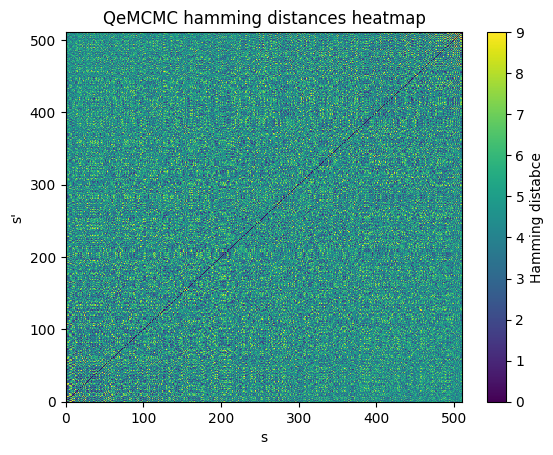

In [33]:

h_dists_flat = hamming_distances_ordered.flatten()


plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=h_dists_flat)#, norm="log")

plt.title("QeMCMC hamming distances heatmap")
plt.xlabel("s")
plt.ylabel("s'")
plt.colorbar(label="Hamming distabce")
plt.show()

lets reorder the configrations, so that valid configurations are first, and replot the hamming distances. You'll see via the red dotted lines that only a small portion of configurations are valid

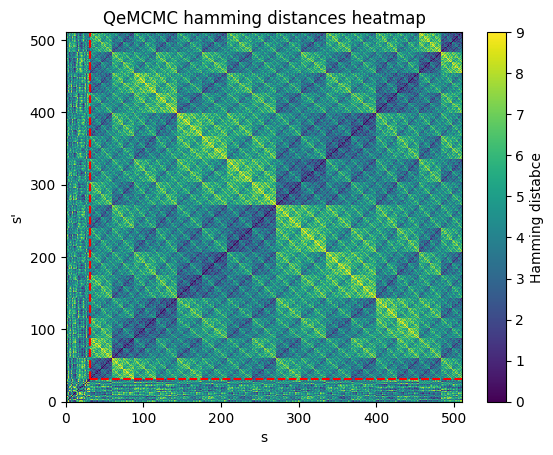

In [34]:

# Find the order, where the valid configurations (those that satisfy the constraints) are at the front, and the invalid ones are at the back
E_unconstrained_order = np.argsort(E_s)
E_s_constrained = np.array([E_s_ if constraint_checker_func(S[i]) else 1000 for i, E_s_ in enumerate(E_s)])
E_s_constrained_order = np.argsort(E_s_constrained)
number_valid_configs = np.sum(E_s_constrained < 99)
# plot the proposals between s and s', where the color is the haming distance
h_dists_ordered_constrained = hamming_distances[E_s_constrained_order, :][:, E_s_constrained_order]


plt.plot([number_valid_configs-0.5, number_valid_configs-0.5], [number_valid_configs-0.5, 2**n_spins], color='red', linestyle='--')
plt.plot([number_valid_configs-0.5, 2**n_spins], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
h_dists_constrained_flat = h_dists_ordered_constrained.flatten()

plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=h_dists_constrained_flat)#, norm="log")

plt.title("QeMCMC hamming distances heatmap")
plt.xlabel("s")
plt.ylabel("s'")
plt.colorbar(label="Hamming distabce")
plt.show()


Lets "zoom in" on the s that are valid, and you should see some structure in the valid configurations. The invalid and valid configurations are demarked by the red line again

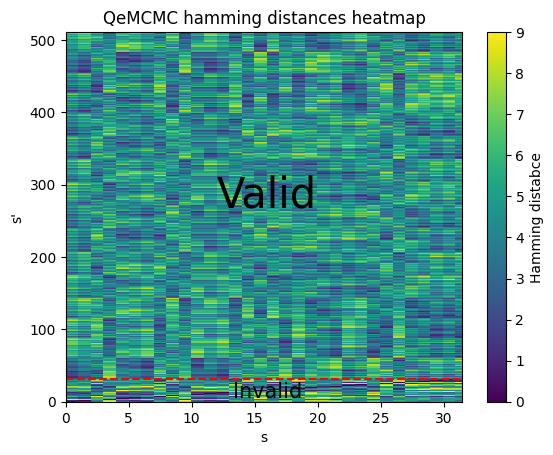

In [35]:
plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=h_dists_constrained_flat)#, norm="log")
plt.plot([0, number_valid_configs-0.5], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
plt.xlim(0, number_valid_configs-0.5)
plt.title("QeMCMC hamming distances heatmap")

# write valid and invalid to make it clear which is which on the plot
plt.text(number_valid_configs/2, 2**(n_spins-1), "Valid", ha='center', va='bottom', color='k', size = 30)
plt.text(number_valid_configs/2, 0, "Invalid", ha='center', va='bottom', color='k', size=15)  

plt.xlabel("s")
plt.ylabel("s'")
plt.colorbar(label="Hamming distabce")
plt.show()

# Simulate classical proposals

Using classical_mcmc, lets generate the proposal distruibutions

100%|██████████| 512/512 [00:00<00:00, 1282.06it/s]


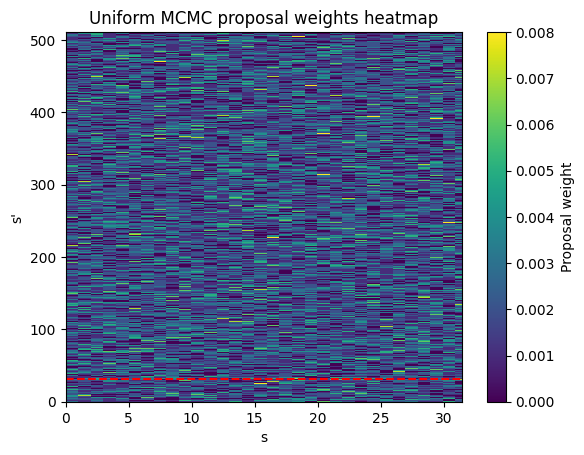

probability of proposing an invalid configuration with uniform proposal:  0.93725


In [36]:
# How many times to sample each proposal
reps = 1000

uniform_proposal = ClassicalProposal(constraint_model,method = "uniform")
uniform_weights_sample = np.zeros_like(E_diffs)
self_proposals = 0
for i, s in enumerate(tqdm.tqdm(S)):
    if constraint_checker_func(s):
        for j in range(reps):
            state = uniform_proposal.update(s)
            state_int = int(state, 2)
            uniform_weights_sample[i, state_int] += 1
uniform_weights_sample = uniform_weights_sample / (reps)
uniform_weights_sample_ordered = uniform_weights_sample[E_s_constrained_order, :][:, E_s_constrained_order]




plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=uniform_weights_sample_ordered.flatten())#, norm="log")
plt.title("Uniform MCMC proposal weights heatmap")
plt.plot([0, number_valid_configs-0.5], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
plt.xlim(0, number_valid_configs-0.5)
plt.xlabel("s")
plt.ylabel("s'")
plt.colorbar(label="Proposal weight")
plt.show()

print("probability of proposing an invalid configuration with uniform proposal: ", np.sum(uniform_weights_sample[:, number_valid_configs:]) / np.sum(uniform_weights_sample))

100%|██████████| 512/512 [00:00<00:00, 2874.20it/s]


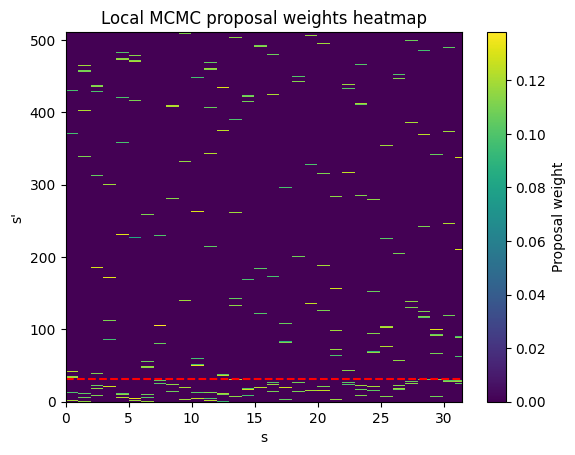

probability of proposing an invalid configuration with local proposal:  0.90415625


In [37]:
# How many times to sample each proposal
reps = 1000
local_proposal = ClassicalProposal(constraint_model, method = "local")
local_weights_sample = np.zeros_like(E_diffs)
self_proposals = 0
for i, s in enumerate(tqdm.tqdm(S)):
    if constraint_checker_func(s):
        for j in range(reps):
            state = local_proposal.update(s)
            state_int = int(state, 2)
            local_weights_sample[i, state_int] += 1
local_weights_sample = local_weights_sample / (reps)
local_weights_sample_ordered = local_weights_sample[E_s_constrained_order, :][:, E_s_constrained_order]




plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=local_weights_sample_ordered.flatten())#, norm="log")
plt.title("Local MCMC proposal weights heatmap")
plt.plot([0, number_valid_configs-0.5], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
plt.xlim(0, number_valid_configs-0.5)
plt.xlabel("s")
plt.ylabel("s'")
plt.colorbar(label="Proposal weight")
plt.show()

print("probability of proposing an invalid configuration with local proposal: ", np.sum(local_weights_sample[:, number_valid_configs:]) / np.sum(local_weights_sample))

The uniform proposal of course has a very uniform distribution, while the local proposal has a sparse and structured distribution. Note that the configurations are ordered (on both axis) by their energy.
Of course, both methods perform many invalid proposals (those which start in a valid configuration, s, and transition to an invalid configuration, s')

# Quantum-enhanced proposals

Lets see how the quantum proposal distribution looks. First, lets ignore the constraints wrt. QeMCMC

In [38]:
# QeMCMC parameters
gamma = 0.45
time = 10

  0%|          | 0/512 [00:00<?, ?it/s]

Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]


  0%|          | 1/512 [00:00<04:35,  1.85it/s]

Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1

  1%|          | 5/512 [00:01<01:31,  5.55it/s]

...

Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1

 99%|█████████▉| 508/512 [00:22<00:00, 15.16it/s]

Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1

100%|██████████| 512/512 [00:23<00:00, 22.18it/s]

Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.165 0.165]


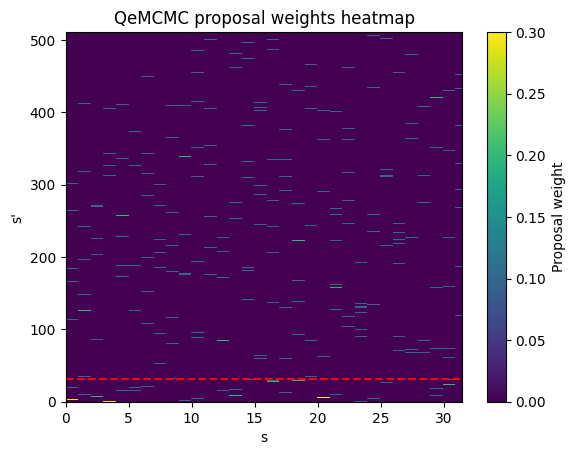

probability of proposing an invalid configuration with qemcmc proposal:  0.8375


In [39]:
# How many times to sample each proposal
reps = 10
# brute force method to get QeMCMC weights
quantum_proposal = QeProposal(base_model, gamma=gamma, time=time, coupling_weights=[0.3,0.3])
qemcmc_weights_sample = np.zeros_like(E_diffs)
self_proposals = 0
for i, s in enumerate(tqdm.tqdm(S)):
    if constraint_checker_func(s):
        for j in range(reps):
            state = quantum_proposal.update(s)
            state_int = int(state, 2)
            qemcmc_weights_sample[i, state_int] += 1
qemcmc_weights_sample = qemcmc_weights_sample / (reps)

qemcmc_weights_sample_ordered = qemcmc_weights_sample[E_s_constrained_order, :][:, E_s_constrained_order]
# make the color graident logarithmic

plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=qemcmc_weights_sample_ordered.flatten())#, norm="log")
plt.plot([0, number_valid_configs-0.5], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
plt.xlim(0, number_valid_configs-0.5)
plt.title("QeMCMC proposal weights heatmap")
plt.xlabel("s")
plt.ylabel("s'")
plt.colorbar(label="Proposal weight")
plt.show()

print("probability of proposing an invalid configuration with qemcmc proposal: ", np.sum(qemcmc_weights_sample_ordered[:, number_valid_configs:]) / np.sum(qemcmc_weights_sample_ordered))

Again, there are many unwanted transitions to invalid configurations.

# Constrained Qe proposal

  0%|          | 0/512 [00:00<?, ?it/s]

Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1

  0%|          | 1/512 [00:00<04:21,  1.95it/s]

Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1

  1%|          | 5/512 [00:01<01:36,  5.23it/s]

...

Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]


 99%|█████████▉| 508/512 [00:15<00:00, 23.33it/s]

Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1

100%|██████████| 512/512 [00:16<00:00, 31.53it/s]

Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]
Sampled hyperparameters for this proposal step: gamma=0.450, time=10, coupling_weights=[0.1 0.1 0.6]


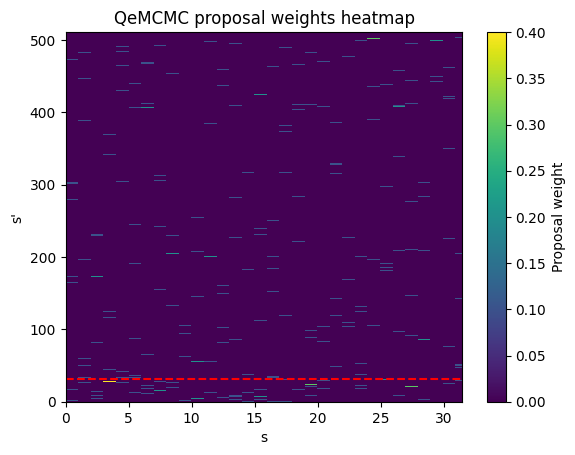

probability of proposing an invalid configuration with qe constrained proposal:  0.7375


In [40]:
# How many times to sample each proposal
reps = 10
# brute force method to get QeMCMC weights
quantum_proposal = QeProposal(constraint_model, gamma=gamma, time=time, coupling_weights=np.array([0.1,0.1,0.6])/(1-gamma))
qemcmc_constr_weights_sample = np.zeros_like(E_diffs)
self_proposals = 0
for i, s in enumerate(tqdm.tqdm(S)):
    if constraint_checker_func(s):
        for j in range(reps):
            state = quantum_proposal.update(s)
            state_int = int(state, 2)
            qemcmc_constr_weights_sample[i, state_int] += 1
qemcmc_constr_weights_sample = qemcmc_constr_weights_sample / (reps)

qemcmc_constr_weights_sample_ordered = qemcmc_constr_weights_sample[E_s_constrained_order, :][:, E_s_constrained_order]
# make the color graident logarithmic
plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=qemcmc_constr_weights_sample_ordered.flatten())#, norm="log")
plt.title("QeMCMC proposal weights heatmap")
plt.xlabel("s")
plt.plot([0, number_valid_configs-0.5], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
plt.xlim(0, number_valid_configs-0.5)
plt.ylabel("s'")
plt.colorbar(label="Proposal weight")
plt.show()


print("probability of proposing an invalid configuration with qe constrained proposal: ", np.sum(qemcmc_constr_weights_sample_ordered[:, number_valid_configs:]) / np.sum(qemcmc_constr_weights_sample))


switch to state vector simulation to speed things up (instead of sampling)

  0%|          | 0/512 [00:00<?, ?it/s]

100%|██████████| 512/512 [00:01<00:00, 282.61it/s]


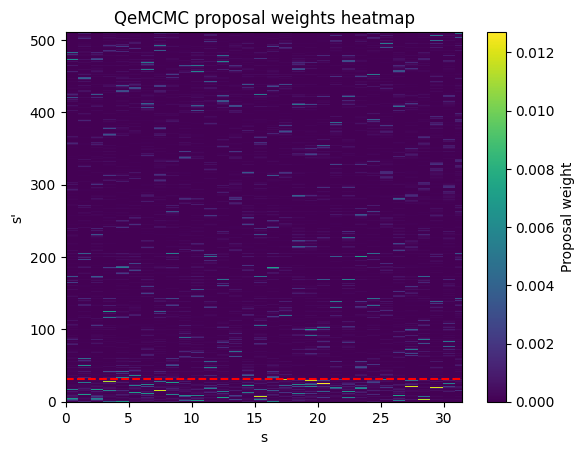

probability of proposing an invalid configuration with qe constrained proposal:  0.7380442564560491


In [41]:
# How many times to sample each proposal
reps = 10
# brute force method to get QeMCMC weights
quantum_proposal = QeProposal(constraint_model, gamma=gamma, time=time, coupling_weights=[0.1,0.1,0.6])
qemcmc_constr_weights_sample = np.zeros_like(E_diffs)
self_proposals = 0
for i, s in enumerate(tqdm.tqdm(S)):
    if constraint_checker_func(s):

        probabilities = np.abs(quantum_proposal.CM.get_state_vector(s, quantum_proposal.coupling_weights, time, quantum_proposal.gamma)) ** 2
        qemcmc_constr_weights_sample[int(i),:] += probabilities
qemcmc_constr_weights_sample = qemcmc_constr_weights_sample / (reps)

qemcmc_constr_weights_sample_ordered = qemcmc_constr_weights_sample[E_s_constrained_order, :][:, E_s_constrained_order]
# make the color graident logarithmic
plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=qemcmc_constr_weights_sample_ordered.flatten())#, norm="log")
plt.title("QeMCMC proposal weights heatmap")
plt.xlabel("s")
plt.plot([0, number_valid_configs-0.5], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
plt.xlim(0, number_valid_configs-0.5)
plt.ylabel("s'")
plt.colorbar(label="Proposal weight")
plt.show()


print("probability of proposing an invalid configuration with qe constrained proposal: ", np.sum(qemcmc_constr_weights_sample_ordered[:, number_valid_configs:]) / np.sum(qemcmc_constr_weights_sample))


How do we know how much weight to apply to the constraint Hamiltonian? Lets do a simple experiment to find a decent value

In [42]:

self_proposals_percent_list_state_vector = []
invalid_proposals_percent_list_state_vector = []
weights_list_state_vector = []

gamma_constrains = np.linspace(0.3, 0.9,10)
for constraint_weight in gamma_constrains:
    qemcmc_weights = np.zeros_like(E_diffs)
    for i, s in enumerate(tqdm.tqdm(S)):
        if constraint_checker_func(s):
            problem_weight = 0.1
            mixing_gamma = 1-(problem_weight + constraint_weight)

            coupling_weights = [problem_weight, problem_weight, constraint_weight]
            # Dont have to do this for statevector approach
            #coupling_weights = coupling_weights/(1-mixing_gamma)
            #gammas = [problem_weight, problem_weight, constraint_weight]

            
            
            probabilities = np.abs(quantum_proposal.CM.get_state_vector(s, coupling_weights, time, mixing_gamma)) ** 2
            qemcmc_weights[int(i),:] += probabilities

            if np.any(np.isnan(probabilities)):  # Check for NaN values
                print("nan probabilities for state: ", s, " with gammas: ", coupling_weights)

    qemcmc_weights = np.round(qemcmc_weights, decimals=3)
    qemcmc_weights_ordered = qemcmc_weights[E_s_constrained_order, :][:, E_s_constrained_order]


    # plt.plot([number_valid_configs-0.5, number_valid_configs-0.5], [number_valid_configs-0.5, 2**n_spins], color='red', linestyle='--')
    # plt.plot([number_valid_configs-0.5, 2**n_spins], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
    # plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=qemcmc_weights_ordered.flatten(), norm="log")
    # plt.plot([0, number_valid_configs-0.5], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
    # plt.xlim(-0.5, number_valid_configs-0.5)
    # plt.title("QeMCMC proposal weights heatmap")
    # plt.xlabel("s")
    # plt.ylabel("s'")
    # plt.colorbar(label="Proposal weight")
    # plt.show()
    # plt.show()
    self_proposals_percent = (100 * np.sum(np.diag(qemcmc_weights))) / (number_valid_configs)

    


    #print("violating proposals percent:", 100 * np.sum(qemcmc_weights_ordered[E_s_constrained<99, E_s_constrained>99]) / (number_valid_configs))

    M = 2**n_spins

    mid = number_valid_configs #M // 2
    weights_2d = qemcmc_weights_ordered.reshape(M, M)
    top_left_sum = np.sum(weights_2d[:mid, mid:])
    bottom_right_sum = np.sum(weights_2d[mid:, :mid])
    total_sum = np.sum(weights_2d)

    # Calculate percentage
    percentage = ((top_left_sum + bottom_right_sum) / total_sum) * 100

    #print(f"Percentage Of invalid proposals quadrants: {percentage:.2f}%")

    self_proposals_percent_list_state_vector.append(self_proposals_percent)
    invalid_proposals_percent_list_state_vector.append(percentage)


    weights_list_state_vector.append(qemcmc_weights)


  0%|          | 0/512 [00:00<?, ?it/s]

100%|██████████| 512/512 [00:01<00:00, 294.79it/s]


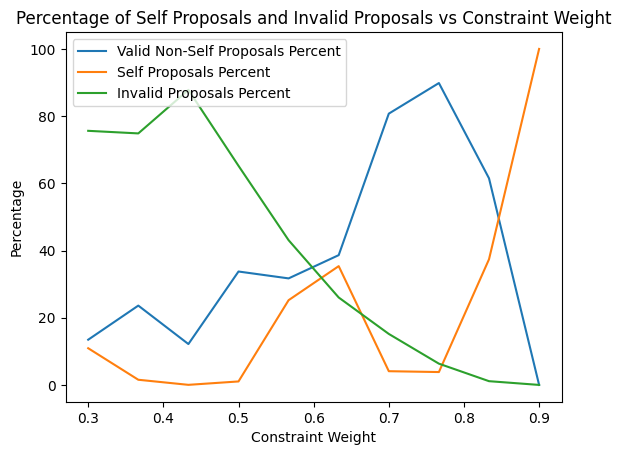

The maximum valid non-self proposal percentage is:  89.8425856897692  at gamma constraint:  0.7666666666666668


In [43]:

valid_non_self_proposals_percent_list_state_vector = 100 - np.array(self_proposals_percent_list_state_vector) - np.array(invalid_proposals_percent_list_state_vector)
plt.plot(gamma_constrains, valid_non_self_proposals_percent_list_state_vector, label="Valid Non-Self Proposals Percent")
plt.plot(gamma_constrains, self_proposals_percent_list_state_vector, label="Self Proposals Percent")
plt.plot(gamma_constrains, invalid_proposals_percent_list_state_vector, label="Invalid Proposals Percent")
plt.xlabel("Constraint Weight")
plt.ylabel("Percentage")
plt.title("Percentage of Self Proposals and Invalid Proposals vs Constraint Weight")
plt.legend()
plt.show()

best_constraint_weight = gamma_constrains[np.argmax(valid_non_self_proposals_percent_list_state_vector)]
print("The maximum valid non-self proposal percentage is: ", np.max(valid_non_self_proposals_percent_list_state_vector), " at gamma constraint: ", best_constraint_weight)



# Hamming weight plot

Plot cumulative hamming weight of each proposal to compare

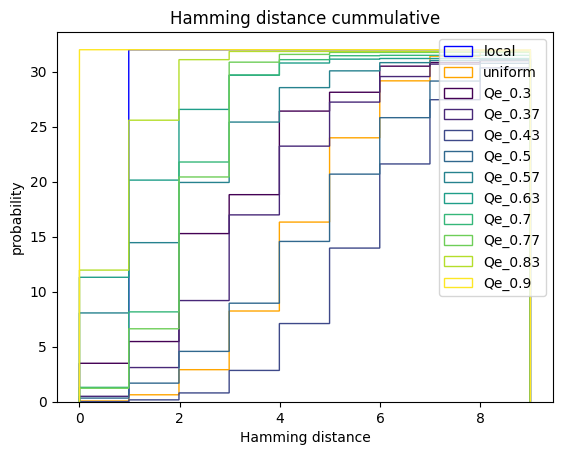

In [44]:


# plot histograms of hamming distances
weights_list_sv = [local_weights_sample, uniform_weights_sample] +    weights_list_state_vector
labels = ["local", "uniform"]+["Qe_"+str(np.round(lab,2)) for lab in gamma_constrains]
colors= ["blue", "orange"] + plt.cm.viridis(np.linspace(0, 1, len(gamma_constrains))).tolist()
for weights, label, color in zip(weights_list_sv, labels, colors):
    plt.hist(hamming_dists.flatten(), bins=2**n_spins, weights=weights.flatten(), density=False, histtype="step", cumulative=True, label=label, color=color)
    # plt.hist(E_diffs.flatten(), bins = n_spins, weights = weights.flatten(), density=True, histtype="step",
    #         cumulative=True, label=label+"_Energy_difference")
plt.legend(loc = "upper right")

plt.title("Hamming distance cummulative")
plt.xlabel("Hamming distance")
plt.ylabel("probability")
plt.show()





# Energy difference plot

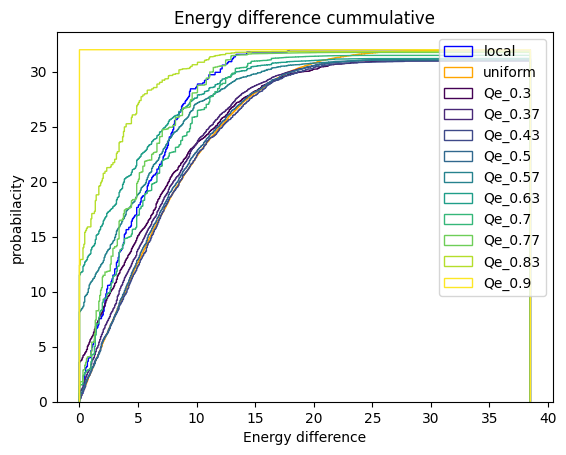

In [45]:
# plot energy difference histograms 
for weights, label, color in zip(weights_list_sv, labels, colors):
    plt.hist(E_diffs.flatten(), bins=2 ** (n_spins), weights=weights.flatten(), density=False, histtype="step", cumulative=True, label=label, color=color)
plt.legend(loc = "upper right")
plt.title("Energy difference cummulative")
plt.xlabel("Energy difference")
plt.ylabel("probabilacity")
plt.show()


# Now that we have chosen an appropriate value for the constraint weight, lets implement a simple QeMCMC

In [46]:
from qemcmc.sampler.runners import ConstrainedMCMCRunner
from qemcmc.utils import plot_chains
from joblib import Parallel, delayed
temp = 0.1
steps = 100
runner = ConstrainedMCMCRunner(constraint_model, temp, constraint_checker_func)

In [47]:
uni_chains = []
uni_rejections = []
for rep in range(reps):
    classical_uniform_MCMC = ClassicalProposal(constraint_model, method="uniform")
    uni_chain, uni_rejection = runner.run(classical_uniform_MCMC, steps, initial_state=constraint_model.initial_state[rep], name="classical uniform MCMC", verbose=False, sample_frequency=1)
    uni_chains.append(uni_chain)
    uni_rejections.append(uni_rejection)


# print average rejections per chain
avg_uni_rejections = np.mean(uni_rejections)/steps
print(f"Average constraint rejections per step: {avg_uni_rejections}")



Average constraint rejections per step: 0.929


In [48]:
loc_chains = []
loc_rejections = []
for rep in range(reps):
    classical_local_MCMC = ClassicalProposal(constraint_model, method="local")
    loc_chain, loc_rejection = runner.run(classical_local_MCMC, steps, initial_state=constraint_model.initial_state[rep], name="classical local MCMC", verbose=False, sample_frequency=1)
    loc_chains.append(loc_chain)
    loc_rejections.append(loc_rejection)

# print average rejections per chain
avg_loc_rejections = np.mean(loc_rejections)/steps
print(f"Average constraint rejections per step: {avg_loc_rejections}")

Average constraint rejections per step: 0.649


In [61]:
m_ = 1 # How many subgroups in (optional) coarse graining
problem_weight = 0.2#mixing_gamma = 1-(problem_weight + best_constraint_weight)
time = (5,15)


mixing_gamma = tuple(1-(problem_weight + np.array([best_constraint_weight+0.05, best_constraint_weight-0.05])))
coupling_weights_ = np.array([problem_weight, problem_weight, best_constraint_weight])
coupling_weights = coupling_weights_/(1-np.mean(mixing_gamma))
print("coupling weights: ", coupling_weights)
print("mixing gamma: ", mixing_gamma)
def run_qemcmc(rep, m, coupling_weights):
    quantum_proposal = QeProposal(constraint_model, gamma=mixing_gamma, time=time, m = m, coupling_weights = coupling_weights)
    return runner.run(quantum_proposal, steps, initial_state=constraint_model.initial_state[rep], name="QeMCMC", verbose=True, sample_frequency=1)


coupling weights:  [0.25 0.25 0.75]
mixing gamma:  (np.float64(0.1499999999999999), np.float64(0.25))


In [62]:

# Run in parallel as they can take a while.
output = Parallel(n_jobs=-1)(delayed(run_qemcmc)(rep, m_, coupling_weights_) for rep in range(reps))

output = np.array(output)
qe_chains = output[:, 0]
Qe_rejection = output[:, 1]

# print average rejections per chain
avg_rejections = np.mean(Qe_rejection)/steps
print(f"Average constraint rejections per step: {avg_rejections}")

Average constraint rejections per step: 0.32


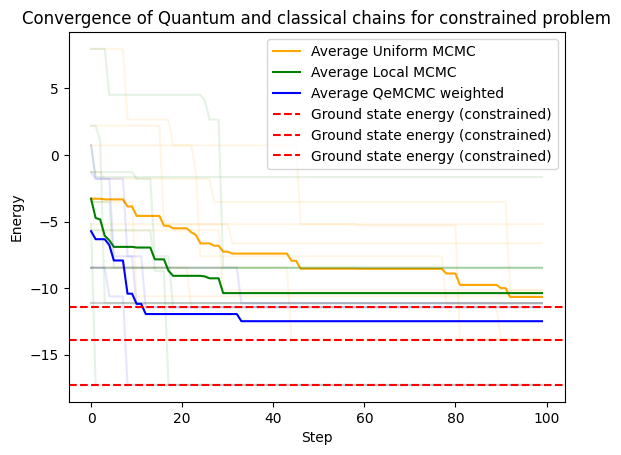

In [63]:
plot_chains(uni_chains, color = 'orange', label="Uniform MCMC")
plot_chains(loc_chains, color = 'green', label="Local MCMC")
plot_chains(qe_chains, color = 'blue', label="QeMCMC weighted")

lowest_energies, degeneracies, lowest_configs = constraint_model.get_lowest_energies(1000, return_configurations=True)
constrained_lowest_energies = []
for i in range(len(lowest_energies)):
    if degeneracies[i] > 1:
        for j in range(degeneracies[i]):
            if constraint_checker_func(lowest_configs[i][j]):
                constrained_lowest_energies.append(lowest_energies[i])
                #plt.axhline(lowest_energies[i], color="red", linestyle="--", label=f"Ground state energy (degeneracy {degeneracies[i]})")
    else:
        if constraint_checker_func(lowest_configs[i][0]):
            constrained_lowest_energies.append(lowest_energies[i])
            #plt.axhline(lowest_energies[i], color="red", linestyle="--", label="Ground state energy")
for i, energy in enumerate(constrained_lowest_energies):
    if i<3:
        plt.axhline(energy, color="red", linestyle="--", label=f"Ground state energy (constrained)")
        
plt.title("Convergence of Quantum and classical chains for constrained problem")
plt.xlabel("Step")
plt.ylabel("Energy")
plt.legend()
plt.show()

In [52]:
#Code for sampler version of the gamma graph
reps = 5
self_proposals_percent_list = []
invalid_proposals_percent_list = []
gamma_constrains = np.linspace(0.5, 1,10)
weights_list = []

for constraint_weight in gamma_constrains:
    qemcmc_weights_sample = np.zeros_like(E_diffs)

    problem_weight = 0
    mixing_gamma = 1-(problem_weight + constraint_weight)
    weights = [problem_weight, problem_weight, constraint_weight]
    quantum_proposal = QeProposal(constraint_model, gamma=mixing_gamma, time=time, coupling_weights=weights)
    for i, s in enumerate(tqdm.tqdm(S)):
        if constraint_checker_func(s):

            for j in range(reps):
                state = quantum_proposal.update(s)
                state_int = int(state, 2)
                qemcmc_weights_sample[i, state_int] += 1
    qemcmc_weights_sample = qemcmc_weights_sample / (reps)
    qemcmc_weights_sample = np.round(qemcmc_weights_sample, decimals=3)
    qemcmc_weights_sample_ordered = qemcmc_weights_sample[E_s_constrained_order, :][:, E_s_constrained_order]


    # plt.plot([number_valid_configs-0.5, number_valid_configs-0.5], [number_valid_configs-0.5, 2**n_spins], color='red', linestyle='--')
    # plt.plot([number_valid_configs-0.5, 2**n_spins], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
    # plt.hist2d(np.repeat(np.arange(2**n_spins), 2**n_spins), np.tile(np.arange(2**n_spins), 2**n_spins), bins=2**n_spins, weights=qemcmc_weights_ordered.flatten(), norm="log")
    # plt.plot([0, number_valid_configs-0.5], [number_valid_configs-0.5, number_valid_configs-0.5], color='red', linestyle='--')
    # plt.xlim(-0.5, number_valid_configs-0.5)
    # plt.title("QeMCMC proposal weights heatmap")
    # plt.xlabel("s")
    # plt.ylabel("s'")
    # plt.colorbar(label="Proposal weight")
    # plt.show()
    # plt.show()
    self_proposals_percent = (100 * np.sum(np.diag(qemcmc_weights_sample))) / (number_valid_configs)

    # normalise
    row_sums = qemcmc_weights_sample.sum(axis=1)
    qemcmc_weights = qemcmc_weights_sample / row_sums[:, np.newaxis]
    #qemcmc_weights[np.diag_indices_from(qemcmc_weights)] = 0


    #print("violating proposals percent:", 100 * np.sum(qemcmc_weights_ordered[E_s_constrained<99, E_s_constrained>99]) / (number_valid_configs))

    M = 2**n_spins

    mid = number_valid_configs #M // 2
    weights_2d = qemcmc_weights_sample_ordered.reshape(M, M)
    top_left_sum = np.sum(weights_2d[:mid, mid:])
    bottom_right_sum = np.sum(weights_2d[mid:, :mid])
    total_sum = np.sum(weights_2d)

    # Calculate percentage
    percentage = ((top_left_sum + bottom_right_sum) / total_sum) * 100

    #print(f"Percentage Of invalid proposals quadrants: {percentage:.2f}%")

    self_proposals_percent_list.append(self_proposals_percent)
    invalid_proposals_percent_list.append(percentage)

    weights_list.append(qemcmc_weights_sample)
    


    

  0%|          | 1/512 [00:00<01:16,  6.65it/s]

Sampled hyperparameters for this proposal step: gamma=0.500, time=12, coupling_weights=[0.   0.   0.25]
Sampled hyperparameters for this proposal step: gamma=0.500, time=12, coupling_weights=[0.   0.   0.25]
Sampled hyperparameters for this proposal step: gamma=0.500, time=13, coupling_weights=[0.   0.   0.25]
Sampled hyperparameters for this proposal step: gamma=0.500, time=12, coupling_weights=[0.   0.   0.25]
Sampled hyperparameters for this proposal step: gamma=0.500, time=12, coupling_weights=[0.   0.   0.25]
Sampled hyperparameters for this proposal step: gamma=0.500, time=8, coupling_weights=[0.   0.   0.25]
Sampled hyperparameters for this proposal step: gamma=0.500, time=9, coupling_weights=[0.   0.   0.25]
Sampled hyperparameters for this proposal step: gamma=0.500, time=10, coupling_weights=[0.   0.   0.25]
Sampled hyperparameters for this proposal step: gamma=0.500, time=8, coupling_weights=[0.   0.   0.25]


  3%|▎         | 17/512 [00:00<00:09, 49.55it/s]

Sampled hyperparameters for this proposal step: gamma=0.500, time=12, coupling_weights=[0.   0.   0.25]
Sampled hyperparameters for this proposal step: gamma=0.500, time=12, coupling_weights=[0.   0.   0.25]
Sampled hyperparameters for this proposal step: gamma=0.500, time=15, coupling_weights=[0.   0.   0.25]
Sampled hyperparameters for this proposal step: gamma=0.500, time=14, coupling_weights=[0.   0.   0.25]
Sampled hyperparameters for this proposal step: gamma=0.500, time=8, coupling_weights=[0.   0.   0.25]
Sampled hyperparameters for this proposal step: gamma=0.500, time=15, coupling_weights=[0.   0.   0.25]
Sampled hyperparameters for this proposal step: gamma=0.500, time=6, coupling_weights=[0.   0.   0.25]


  4%|▍         | 22/512 [00:00<00:13, 35.35it/s]

...

Sampled hyperparameters for this proposal step: gamma=0.000, time=7, coupling_weights=[0. 0. 1.]
Sampled hyperparameters for this proposal step: gamma=0.000, time=5, coupling_weights=[0. 0. 1.]
Sampled hyperparameters for this proposal step: gamma=0.000, time=6, coupling_weights=[0. 0. 1.]
Sampled hyperparameters for this proposal step: gamma=0.000, time=8, coupling_weights=[0. 0. 1.]
Sampled hyperparameters for this proposal step: gamma=0.000, time=11, coupling_weights=[0. 0. 1.]
Sampled hyperparameters for this proposal step: gamma=0.000, time=15, coupling_weights=[0. 0. 1.]
Sampled hyperparameters for this proposal step: gamma=0.000, time=13, coupling_weights=[0. 0. 1.]
Sampled hyperparameters for this proposal step: gamma=0.000, time=5, coupling_weights=[0. 0. 1.]
Sampled hyperparameters for this proposal step: gamma=0.000, time=5, coupling_weights=[0. 0. 1.]
Sampled hyperparameters for this proposal step: gamma=0.000, time=10, coupling_weights=[0. 0. 1.]
Sampled hyperparameters fo

 98%|█████████▊| 501/512 [00:05<00:00, 95.77it/s] 

Sampled hyperparameters for this proposal step: gamma=0.000, time=5, coupling_weights=[0. 0. 1.]
Sampled hyperparameters for this proposal step: gamma=0.000, time=10, coupling_weights=[0. 0. 1.]
Sampled hyperparameters for this proposal step: gamma=0.000, time=8, coupling_weights=[0. 0. 1.]
Sampled hyperparameters for this proposal step: gamma=0.000, time=10, coupling_weights=[0. 0. 1.]
Sampled hyperparameters for this proposal step: gamma=0.000, time=15, coupling_weights=[0. 0. 1.]
Sampled hyperparameters for this proposal step: gamma=0.000, time=5, coupling_weights=[0. 0. 1.]
Sampled hyperparameters for this proposal step: gamma=0.000, time=15, coupling_weights=[0. 0. 1.]
Sampled hyperparameters for this proposal step: gamma=0.000, time=8, coupling_weights=[0. 0. 1.]


100%|██████████| 512/512 [00:05<00:00, 87.30it/s]

Sampled hyperparameters for this proposal step: gamma=0.000, time=8, coupling_weights=[0. 0. 1.]
Sampled hyperparameters for this proposal step: gamma=0.000, time=5, coupling_weights=[0. 0. 1.]


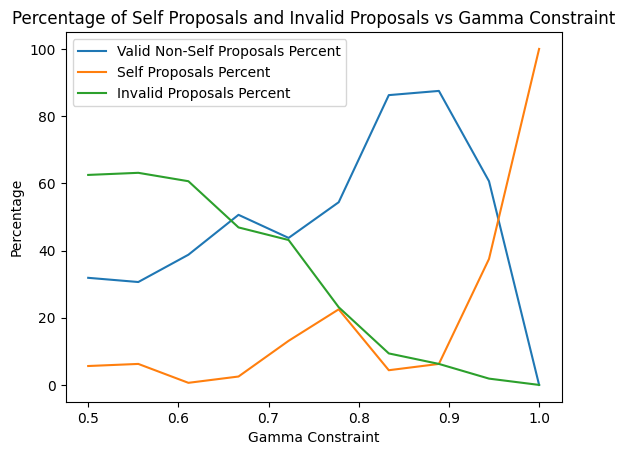

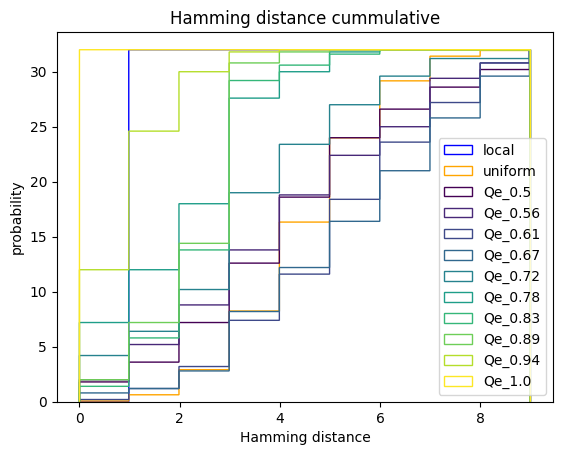

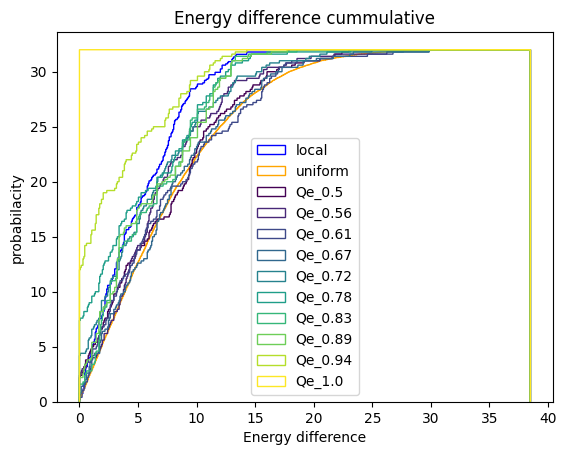

In [53]:

valid_non_self_proposals_percent_list = 100 - np.array(self_proposals_percent_list) - np.array(invalid_proposals_percent_list)
plt.plot(gamma_constrains, valid_non_self_proposals_percent_list, label="Valid Non-Self Proposals Percent")
plt.plot(gamma_constrains, self_proposals_percent_list, label="Self Proposals Percent")
plt.plot(gamma_constrains, invalid_proposals_percent_list, label="Invalid Proposals Percent")
plt.xlabel("Gamma Constraint")
plt.ylabel("Percentage")
plt.title("Percentage of Self Proposals and Invalid Proposals vs Gamma Constraint")
plt.legend()
plt.show()





# plot histograms of hamming distances
weights_list_ = [local_weights_sample, uniform_weights_sample] + weights_list
labels = ["local", "uniform"]+["Qe_"+str(np.round(lab,2)) for lab in gamma_constrains]
colors= ["blue", "orange"] + plt.cm.viridis(np.linspace(0, 1, len(gamma_constrains))).tolist()
for weights, label, color in zip(weights_list_, labels, colors):
    plt.hist(hamming_dists.flatten(), bins=2**n_spins, weights=weights.flatten(), density=False, histtype="step", cumulative=True, label=label, color=color)
    # plt.hist(E_diffs.flatten(), bins = n_spins, weights = weights.flatten(), density=True, histtype="step",
    #         cumulative=True, label=label+"_Energy_difference")
plt.legend()
plt.title("Hamming distance cummulative")
plt.xlabel("Hamming distance")
plt.ylabel("probability")
plt.show()



# plot energy difference histograms 
for weights, label, color in zip(weights_list_, labels, colors):
    plt.hist(E_diffs.flatten(), bins=2 ** (n_spins), weights=weights.flatten(), density=False, histtype="step", cumulative=True, label=label, color=color)
plt.legend()
plt.title("Energy difference cummulative")
plt.xlabel("Energy difference")
plt.ylabel("probabilacity")
plt.show()